# CODE CNN CƠ BẢN + 3 MÔ HÌNH CẢI TIẾN TRÊN CIFAR-10

**File dự kiến đặt tại:**

`C:\Users\datng\Desktop\GIÁO TRÌNH\NĂM 4 - KÌ 1\PTCHTTH - Phát Triển Các Hệ Thống Thông Minh\test\a05\data2_cifar_10\preprocessor.ipynb`

**Dataset đầu vào:**

`C:\DATA\CIFAR-10`

Notebook này triển khai đầy đủ:

1. Kiểm tra cấu trúc CIFAR-10 tải từ Kaggle.
2. Đọc `trainLabels.csv` và ảnh trong thư mục `train`.
3. Chia dữ liệu có nhãn thành train / validation / test nội bộ.
4. Tính mean/std từ riêng tập train.
5. Data Augmentation cho tập train.
6. Xây dựng **CNN cơ bản**.
7. Xây dựng **ResNet** với residual connection `F(x) + x`.
8. Xây dựng **VGGNet-style** bằng nhiều `Conv 3×3`.
9. Xây dựng **MobileNet-style** bằng Depthwise + Pointwise Convolution.
10. Huấn luyện 4 mô hình bằng cùng protocol.
11. Đánh giá Accuracy, Loss, số Parameters, thời gian training.
12. Visualization learning curve, confusion matrix và prediction mẫu.
13. Lưu model và bảng kết quả.

> CIFAR-10 là ảnh RGB kích thước `32×32`, nên input PyTorch có dạng `N × 3 × 32 × 32`.

## 1. Import thư viện và cấu hình môi trường

In [ ]:
# Import Path để xử lý đường dẫn file/thư mục trên Windows.
from pathlib import Path

# Import time để đo thời gian huấn luyện của từng mô hình.
import time

# Import copy để sao chép state_dict tốt nhất trong quá trình validation.
import copy

# Import random để đặt seed cho Python.
import random

# Import NumPy để xử lý mảng số.
import numpy as np

# Import Pandas để đọc file trainLabels.csv và tạo bảng kết quả.
import pandas as pd

# Import PIL.Image để đọc ảnh PNG/JPG từ ổ đĩa.
from PIL import Image

# Import Matplotlib để trực quan hóa ảnh và metric.
import matplotlib.pyplot as plt

# Import PyTorch.
import torch

# Import torch.nn để dùng các layer neural network.
import torch.nn as nn

# Import functional API như relu.
import torch.nn.functional as F

# Import Dataset để tự xây dựng dataset từ ảnh PNG + CSV.
from torch.utils.data import Dataset

# Import DataLoader để chia dataset thành mini-batch.
from torch.utils.data import DataLoader

# Import torchvision transforms để augmentation và normalize ảnh.
from torchvision import transforms

# Import train_test_split để chia train/validation/test.
from sklearn.model_selection import train_test_split

# Import confusion_matrix để phân tích lỗi nhầm giữa 10 lớp.
from sklearn.metrics import confusion_matrix

# Import classification_report để tính precision/recall/F1.
from sklearn.metrics import classification_report

# Seed cố định giúp kết quả tái lập tốt hơn.
SEED = 42

# Đặt seed cho Python.
random.seed(SEED)

# Đặt seed cho NumPy.
np.random.seed(SEED)

# Đặt seed cho PyTorch CPU.
torch.manual_seed(SEED)

# Nếu có NVIDIA CUDA thì đặt seed cho GPU.
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Ưu tiên thuật toán deterministic.
torch.backends.cudnn.deterministic = True

# Tắt benchmark để tăng tính tái lập.
torch.backends.cudnn.benchmark = False

# Tự động chọn RTX 3060 nếu PyTorch CUDA đã được cài đúng.
DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# In thông tin môi trường hiện tại.
print("Python/Torch environment:")
print("PyTorch version :", torch.__version__)
print("CUDA build      :", torch.version.cuda)
print("CUDA available  :", torch.cuda.is_available())
print("DEVICE          :", DEVICE)

# Nếu CUDA khả dụng thì in tên GPU.
if torch.cuda.is_available():
    print("GPU             :", torch.cuda.get_device_name(0))
else:
    print("CẢNH BÁO: PyTorch chưa thấy CUDA. Notebook vẫn chạy được bằng CPU nhưng sẽ chậm hơn.")

Python/Torch environment:
PyTorch version : 2.5.1+cu121
CUDA build      : 12.1
CUDA available  : True
DEVICE          : cuda:0
GPU             : NVIDIA GeForce RTX 3060 Laptop GPU


## 2. Khai báo đường dẫn CIFAR-10

Notebook ưu tiên cấu trúc Kaggle:

```text
C:\DATA\CIFAR-10
├── trainLabels.csv
├── train│   ├── 1.png
│   ├── 2.png
│   └── ...
└── test    ├── 1.png
    ├── 2.png
    └── ...
```

Nếu bạn mới có `train.7z` hoặc `test.7z` thì cần giải nén trước.

In [ ]:
# Khai báo thư mục gốc của CIFAR-10.
DATA_DIR = Path(r"C:\DATA\CIFAR-10")

# Các tên file label thường gặp.
LABEL_FILE_CANDIDATES = [
    "trainLabels.csv",
    "train_labels.csv",
    "labels.csv",
]

# Các tên folder train thường gặp.
TRAIN_DIR_CANDIDATES = [
    "train",
    "Train",
    "training",
]

# Các tên folder test thường gặp.
TEST_DIR_CANDIDATES = [
    "test",
    "Test",
    "testing",
]


# Hàm tìm file đầu tiên tồn tại.
def resolve_file(directory: Path, candidates: list[str]) -> Path:
    # Duyệt lần lượt từng tên file có thể có.
    for filename in candidates:
        # Ghép thành đường dẫn đầy đủ.
        candidate = directory / filename

        # Nếu tồn tại đúng là file thì trả về.
        if candidate.is_file():
            return candidate

    # Nếu không tìm được thì báo lỗi rõ ràng.
    raise FileNotFoundError(f"Không tìm thấy file label trong {directory}. Đã thử: {candidates}")


# Hàm tìm folder đầu tiên tồn tại.
def resolve_directory(directory: Path, candidates: list[str]) -> Path:
    # Duyệt từng tên folder.
    for dirname in candidates:
        # Ghép path.
        candidate = directory / dirname

        # Nếu tồn tại đúng là directory thì trả về.
        if candidate.is_dir():
            return candidate

    # Nếu không tìm được thì báo lỗi.
    raise FileNotFoundError(
        f"Không tìm thấy thư mục ảnh train trong {directory}. Đã thử: {candidates}"
    )


# Kiểm tra thư mục gốc CIFAR-10.
if not DATA_DIR.exists():
    raise FileNotFoundError(
        f"Không tồn tại thư mục: {DATA_DIR}\nHãy kiểm tra lại C:\\DATA\\CIFAR-10."
    )

# Tìm file trainLabels.csv.
LABEL_FILE = resolve_file(
    DATA_DIR,
    LABEL_FILE_CANDIDATES,
)

# Tìm folder train.
TRAIN_IMAGE_DIR = resolve_directory(
    DATA_DIR,
    TRAIN_DIR_CANDIDATES,
)

# Khởi tạo test folder là None vì test competition không bắt buộc cho metric.
TEST_IMAGE_DIR = None

# Thử tìm folder test nếu có.
for dirname in TEST_DIR_CANDIDATES:
    # Tạo candidate.
    candidate = DATA_DIR / dirname

    # Nếu tồn tại thì lưu lại.
    if candidate.is_dir():
        TEST_IMAGE_DIR = candidate
        break

# In cấu trúc đã nhận diện.
print("LABEL_FILE      =", LABEL_FILE)
print("TRAIN_IMAGE_DIR =", TRAIN_IMAGE_DIR)
print("TEST_IMAGE_DIR  =", TEST_IMAGE_DIR)

# Kiểm tra xem còn file .7z chưa giải nén không.
archives = list(DATA_DIR.glob("*.7z"))

# Nếu có thì cảnh báo.
if archives:
    print("\nPhát hiện archive .7z:")
    for archive in archives:
        print(" -", archive)

LABEL_FILE      = C:\DATA\CIFAR-10\trainLabels.csv
TRAIN_IMAGE_DIR = C:\DATA\CIFAR-10\train
TEST_IMAGE_DIR  = None


## 3. Đọc `trainLabels.csv` và tạo mapping 10 lớp

In [ ]:
# Đọc CSV chứa id ảnh và label.
labels_df = pd.read_csv(LABEL_FILE)

# Hiển thị 5 dòng đầu.
display(labels_df.head())

# In shape bảng nhãn.
print("labels_df.shape =", labels_df.shape)

# In danh sách cột.
print("Columns =", labels_df.columns.tolist())

# Kiểm tra bắt buộc có cột label.
if "label" not in labels_df.columns:
    raise ValueError("Không tìm thấy cột 'label' trong file nhãn.")

# Nếu có cột id thì dùng trực tiếp.
if "id" in labels_df.columns:
    image_id_col = "id"
else:
    # Nếu không có tên id thì lấy cột đầu tiên làm image id.
    image_id_col = labels_df.columns[0]

# Lấy danh sách class duy nhất và sắp xếp alphabet.
CLASS_NAMES = sorted(labels_df["label"].astype(str).unique().tolist())

# CIFAR-10 phải có đúng 10 class.
if len(CLASS_NAMES) != 10:
    raise ValueError(f"Kỳ vọng 10 lớp nhưng tìm thấy {len(CLASS_NAMES)}: {CLASS_NAMES}")

# Tạo map từ tên class -> số nguyên.
CLASS_TO_INDEX = {class_name: class_index for class_index, class_name in enumerate(CLASS_NAMES)}

# Tạo map ngược từ index -> tên class.
INDEX_TO_CLASS = {class_index: class_name for class_name, class_index in CLASS_TO_INDEX.items()}

# In mapping.
print("\nClass mapping:")
for class_name, class_index in CLASS_TO_INDEX.items():
    print(f"{class_index}: {class_name}")

,id,label
0,1,frog
1,2,truck
2,3,truck
3,4,deer
4,5,automobile


labels_df.shape = (50000, 2)
Columns = ['id', 'label']

Class mapping:
0: airplane
1: automobile
2: bird
3: cat
4: deer
5: dog
6: frog
7: horse
8: ship
9: truck


## 4. Tạo đường dẫn ảnh từ `id`

In [ ]:
# Hàm tìm file ảnh theo image id.
def find_image_path(image_dir: Path, image_id) -> Path:
    # Chuyển id thành string.
    image_id = str(image_id)

    # Các extension phổ biến.
    extensions = [".png", ".jpg", ".jpeg"]

    # Duyệt từng extension.
    for extension in extensions:
        # Tạo đường dẫn candidate.
        candidate = image_dir / f"{image_id}{extension}"

        # Nếu file tồn tại thì trả về.
        if candidate.is_file():
            return candidate

    # Nếu chưa thấy thì trả path PNG mặc định để dễ debug.
    return image_dir / f"{image_id}.png"


# Tạo cột đường dẫn ảnh.
labels_df["image_path"] = labels_df[image_id_col].apply(
    lambda image_id: str(
        find_image_path(
            TRAIN_IMAGE_DIR,
            image_id,
        )
    )
)

# Convert tên class thành index số nguyên.
labels_df["label_index"] = labels_df["label"].map(CLASS_TO_INDEX).astype(int)

# Kiểm tra 100 ảnh đầu có tồn tại không.
missing_paths = [path for path in labels_df["image_path"].head(100) if not Path(path).is_file()]

# Nếu có ảnh thiếu thì dừng để tránh train sai.
if missing_paths:
    raise FileNotFoundError("Không tìm thấy ảnh. Ví dụ:\n" + "\n".join(missing_paths[:10]))

# Hiển thị bảng đã hoàn thiện.
display(
    labels_df[
        [
            image_id_col,
            "label",
            "label_index",
            "image_path",
        ]
    ].head()
)

,id,label,label_index,image_path
0,1,frog,6,C:\DATA\CIFAR-10\train\1.png
1,2,truck,9,C:\DATA\CIFAR-10\train\2.png
2,3,truck,9,C:\DATA\CIFAR-10\train\3.png
3,4,deer,4,C:\DATA\CIFAR-10\train\4.png
4,5,automobile,1,C:\DATA\CIFAR-10\train\5.png


## 5. Khảo sát một ảnh CIFAR-10

PIL size = (32, 32)
NumPy shape = (32, 32, 3)


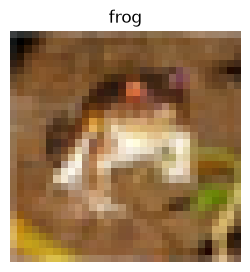

In [ ]:
# Lấy đường dẫn ảnh đầu tiên.
sample_path = Path(labels_df.iloc[0]["image_path"])

# Đọc ảnh và đảm bảo RGB.
sample_image = Image.open(sample_path).convert("RGB")

# In kích thước PIL: (width, height).
print("PIL size =", sample_image.size)

# Chuyển sang NumPy.
sample_array = np.asarray(sample_image)

# In shape NumPy: [H, W, C].
print("NumPy shape =", sample_array.shape)

# Kiểm tra ảnh phải là 32×32×3.
assert sample_array.shape == (32, 32, 3)

# Hiển thị ảnh.
plt.figure(figsize=(3, 3))
plt.imshow(sample_image)
plt.title(labels_df.iloc[0]["label"])
plt.axis("off")
plt.show()

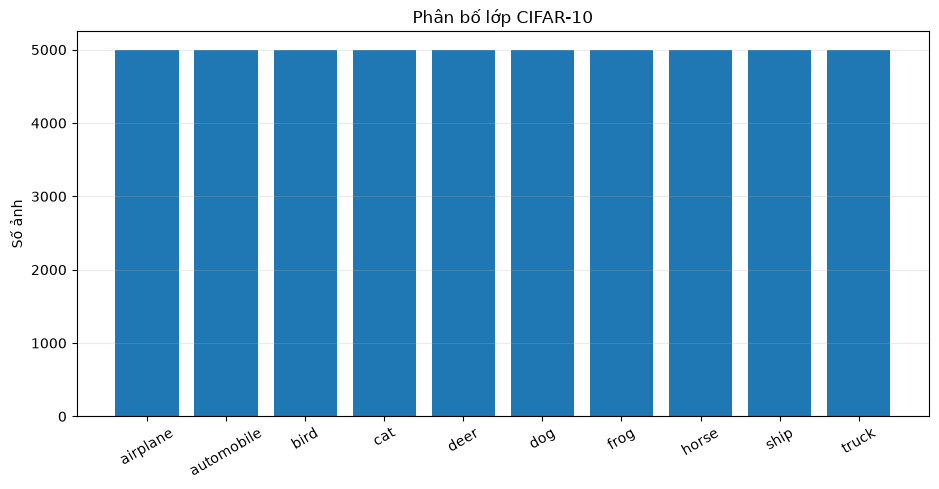

,count
label,
airplane,5000
automobile,5000
bird,5000
cat,5000
deer,5000
dog,5000
frog,5000
horse,5000
ship,5000


In [ ]:
# Đếm số ảnh từng class.
class_distribution = labels_df["label"].value_counts().reindex(CLASS_NAMES)

# Vẽ phân bố class.
plt.figure(figsize=(11, 5))
plt.bar(
    class_distribution.index,
    class_distribution.values,
)
plt.xticks(rotation=30)
plt.ylabel("Số ảnh")
plt.title("Phân bố lớp CIFAR-10")
plt.grid(axis="y", alpha=0.25)
plt.show()

# Hiển thị bảng count.
display(class_distribution.rename("count").to_frame())

## 6. Chia dữ liệu thành Train / Validation / Test nội bộ

Từ dữ liệu có nhãn:

- 80% train
- 10% validation
- 10% test nội bộ

Tập `test` của Kaggle competition không có ground-truth public, nên không phù hợp để tính Accuracy trực tiếp.

In [ ]:
# Tạo toàn bộ index.
all_indices = np.arange(len(labels_df))

# Lấy toàn bộ target dạng số.
all_targets = labels_df["label_index"].to_numpy()

# Chia 80% train và 20% temporary.
train_indices, temp_indices = train_test_split(
    all_indices,
    test_size=0.20,
    random_state=SEED,
    stratify=all_targets,
)

# Lấy target của phần temporary.
temp_targets = all_targets[temp_indices]

# Chia temporary thành 10% validation và 10% test.
val_indices, test_indices = train_test_split(
    temp_indices,
    test_size=0.50,
    random_state=SEED,
    stratify=temp_targets,
)

# In số mẫu.
print("Train      =", len(train_indices))
print("Validation =", len(val_indices))
print("Test       =", len(test_indices))

# Kiểm tra tổng số mẫu.
assert len(train_indices) + len(val_indices) + len(test_indices) == len(labels_df)

Train      = 40000
Validation = 5000
Test       = 5000


## 7. Dataset class đọc ảnh từ ổ đĩa

In [ ]:
# Dataset tùy biến cho Kaggle CIFAR-10.
class CIFAR10KaggleDataset(Dataset):
    # Constructor.
    def __init__(
        self,
        dataframe: pd.DataFrame,
        indices,
        transform=None,
    ):
        # Chỉ lấy các row thuộc split hiện tại.
        self.dataframe = dataframe.iloc[indices].reset_index(drop=True).copy()

        # Lưu transform.
        self.transform = transform

    # Số sample trong dataset.
    def __len__(self):
        return len(self.dataframe)

    # Lấy sample thứ index.
    def __getitem__(self, index):
        # Lấy một row.
        row = self.dataframe.iloc[index]

        # Lấy path ảnh.
        image_path = Path(row["image_path"])

        # Đọc ảnh và convert RGB.
        image = Image.open(image_path).convert("RGB")

        # Lấy label index.
        label = int(row["label_index"])

        # Nếu có transform thì áp dụng.
        if self.transform is not None:
            image = self.transform(image)

        # Trả tensor ảnh và label.
        return image, label

## 8. Tính Mean và Standard Deviation từ Train split

Chỉ dùng train split để tránh data leakage.

In [ ]:
# Transform tạm thời chỉ đổi ảnh sang Tensor [0,1].
stats_transform = transforms.ToTensor()

# Dataset train dùng cho tính thống kê.
stats_dataset = CIFAR10KaggleDataset(
    dataframe=labels_df,
    indices=train_indices,
    transform=stats_transform,
)

# DataLoader tính statistics.
stats_loader = DataLoader(
    stats_dataset,
    batch_size=256,
    shuffle=False,
    num_workers=0,
)

# Tổng pixel theo từng channel.
channel_sum = torch.zeros(3)

# Tổng bình phương pixel theo từng channel.
channel_squared_sum = torch.zeros(3)

# Tổng số pixel trên mỗi channel.
num_pixels_per_channel = 0

# Duyệt toàn bộ train split.
for images, _ in stats_loader:
    # Lấy shape batch.
    batch_size, channels, height, width = images.shape

    # Cộng tổng pixel theo N,H,W.
    channel_sum += images.sum(dim=(0, 2, 3))

    # Cộng tổng bình phương pixel.
    channel_squared_sum += (images**2).sum(dim=(0, 2, 3))

    # Cộng số pixel trên mỗi channel.
    num_pixels_per_channel += batch_size * height * width

# Mean từng channel.
train_mean_tensor = channel_sum / num_pixels_per_channel

# E[x^2].
mean_squared = channel_squared_sum / num_pixels_per_channel

# Variance = E[x^2] - E[x]^2.
train_var_tensor = mean_squared - train_mean_tensor**2

# Standard deviation.
train_std_tensor = torch.sqrt(train_var_tensor)

# Đổi thành tuple Python.
TRAIN_MEAN = tuple(train_mean_tensor.tolist())

# Đổi std thành tuple.
TRAIN_STD = tuple(train_std_tensor.tolist())

# In kết quả.
print("TRAIN_MEAN =", TRAIN_MEAN)
print("TRAIN_STD  =", TRAIN_STD)

TRAIN_MEAN = (0.49109354615211487, 0.48214712738990784, 0.4465755820274353)
TRAIN_STD  = (0.2470078021287918, 0.24354355037212372, 0.2616422772407532)


## 9. Data Augmentation và Normalize

Train:

`RandomCrop + HorizontalFlip + ToTensor + Normalize`

Validation/Test:

`ToTensor + Normalize`

In [ ]:
# Transform dùng khi training.
train_transform = transforms.Compose(
    [
        # Padding 4 pixel rồi random crop về 32×32.
        transforms.RandomCrop(
            size=32,
            padding=4,
        ),
        # Random horizontal flip.
        transforms.RandomHorizontalFlip(),
        # Chuyển PIL -> Tensor [C,H,W].
        transforms.ToTensor(),
        # Normalize theo thống kê train.
        transforms.Normalize(
            mean=TRAIN_MEAN,
            std=TRAIN_STD,
        ),
    ]
)

# Transform validation/test.
eval_transform = transforms.Compose(
    [
        # Không augmentation.
        transforms.ToTensor(),
        # Normalize giống train.
        transforms.Normalize(
            mean=TRAIN_MEAN,
            std=TRAIN_STD,
        ),
    ]
)

## 10. Tạo DataLoader

In [ ]:
# Dataset train.
train_dataset = CIFAR10KaggleDataset(
    labels_df,
    train_indices,
    train_transform,
)

# Dataset validation.
val_dataset = CIFAR10KaggleDataset(
    labels_df,
    val_indices,
    eval_transform,
)

# Dataset test nội bộ.
test_dataset = CIFAR10KaggleDataset(
    labels_df,
    test_indices,
    eval_transform,
)

# Batch size dùng chung.
BATCH_SIZE = 128

# Trên Windows/Jupyter nên bắt đầu với 0 để ổn định.
NUM_WORKERS = 0

# Pin memory nếu dùng CUDA.
PIN_MEMORY = DEVICE.type == "cuda"

# Train loader có shuffle.
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)

# Validation loader.
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)

# Test loader.
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)

# Lấy thử một batch.
sample_images, sample_labels = next(iter(train_loader))

# In shape ảnh.
print(
    "sample_images.shape =",
    sample_images.shape,
)

# In shape labels.
print(
    "sample_labels.shape =",
    sample_labels.shape,
)

# CIFAR-10 phải là 3×32×32.
assert sample_images.shape[1:] == (
    3,
    32,
    32,
)

sample_images.shape = torch.Size([128, 3, 32, 32])
sample_labels.shape = torch.Size([128])


## 11. Visualization ảnh sau preprocessing

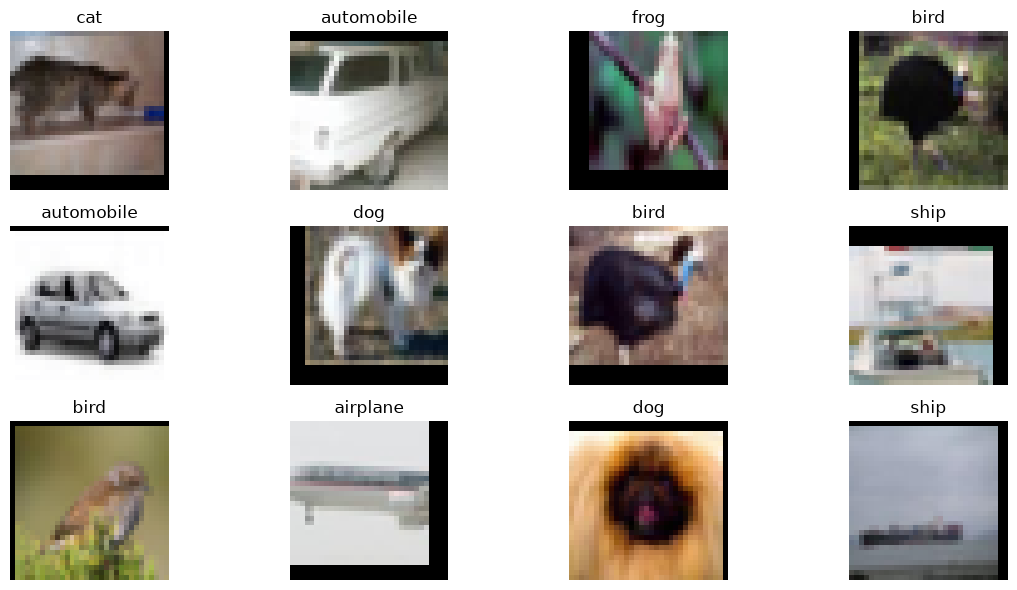

In [ ]:
# Hàm đảo normalize để ảnh hiển thị đúng.
def denormalize_image(
    image_tensor: torch.Tensor,
) -> torch.Tensor:
    # Mean shape [3,1,1].
    mean = torch.tensor(TRAIN_MEAN).view(3, 1, 1)

    # Std shape [3,1,1].
    std = torch.tensor(TRAIN_STD).view(3, 1, 1)

    # Đảo normalize.
    image = image_tensor.cpu() * std + mean

    # Giới hạn về [0,1].
    return image.clamp(
        0.0,
        1.0,
    )


# Tạo figure.
plt.figure(figsize=(12, 6))

# Hiển thị 12 ảnh.
for i in range(12):
    # Tạo subplot.
    plt.subplot(
        3,
        4,
        i + 1,
    )

    # Đảo normalize.
    image = denormalize_image(sample_images[i])

    # [C,H,W] -> [H,W,C].
    image = image.permute(
        1,
        2,
        0,
    ).numpy()

    # Hiển thị.
    plt.imshow(image)

    # Lấy class name.
    class_name = INDEX_TO_CLASS[int(sample_labels[i])]

    # Title.
    plt.title(class_name)

    # Ẩn axis.
    plt.axis("off")

# Căn layout.
plt.tight_layout()

# Show.
plt.show()

# PHẦN B — CNN CƠ BẢN + 3 MÔ HÌNH CẢI TIẾN

## 12. Mô hình 1 — CNN cơ bản

In [13]:
# CNN baseline cho CIFAR-10.
class BasicCNN(nn.Module):
    # Constructor.
    def __init__(
        self,
        num_classes: int = 10,
    ):
        # Khởi tạo nn.Module.
        super().__init__()

        # Block 1: 3 -> 32 channel, 32×32 -> 16×16.
        self.block1 = nn.Sequential(
            nn.Conv2d(
                3,
                32,
                kernel_size=3,
                padding=1,
            ),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
        )

        # Block 2: 32 -> 64 channel, 16×16 -> 8×8.
        self.block2 = nn.Sequential(
            nn.Conv2d(
                32,
                64,
                kernel_size=3,
                padding=1,
            ),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
        )

        # Block 3: 64 -> 128 channel, 8×8 -> 4×4.
        self.block3 = nn.Sequential(
            nn.Conv2d(
                64,
                128,
                kernel_size=3,
                padding=1,
            ),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
        )

        # Classifier.
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(
                128 * 4 * 4,
                256,
            ),
            nn.ReLU(inplace=True),
            nn.Dropout(0.30),
            nn.Linear(
                256,
                num_classes,
            ),
        )

    # Forward.
    def forward(self, x):
        # Feature block 1.
        x = self.block1(x)

        # Feature block 2.
        x = self.block2(x)

        # Feature block 3.
        x = self.block3(x)

        # Logits.
        logits = self.classifier(x)

        # Không softmax trước CrossEntropyLoss.
        return logits

## 13. Mô hình 2 — ResNet

In [ ]:
# Basic residual block.
class BasicBlock(nn.Module):
    # Constructor.
    def __init__(
        self,
        in_channels: int,
        out_channels: int,
        stride: int = 1,
    ):
        # Khởi tạo.
        super().__init__()

        # Conv 3×3 đầu tiên.
        self.conv1 = nn.Conv2d(
            in_channels,
            out_channels,
            kernel_size=3,
            stride=stride,
            padding=1,
            bias=False,
        )

        # BatchNorm 1.
        self.bn1 = nn.BatchNorm2d(out_channels)

        # Conv 3×3 thứ hai.
        self.conv2 = nn.Conv2d(
            out_channels,
            out_channels,
            kernel_size=3,
            stride=1,
            padding=1,
            bias=False,
        )

        # BatchNorm 2.
        self.bn2 = nn.BatchNorm2d(out_channels)

        # Nếu shape thay đổi thì projection shortcut.
        if stride != 1 or in_channels != out_channels:
            # Conv 1×1 khớp shape.
            self.shortcut = nn.Sequential(
                nn.Conv2d(
                    in_channels,
                    out_channels,
                    kernel_size=1,
                    stride=stride,
                    bias=False,
                ),
                nn.BatchNorm2d(out_channels),
            )
        else:
            # Nếu cùng shape thì dùng x trực tiếp.
            self.shortcut = nn.Identity()

    # Forward.
    def forward(self, x):
        # Nhánh shortcut.
        identity = self.shortcut(x)

        # Residual conv1.
        out = self.conv1(x)

        # BN1.
        out = self.bn1(out)

        # ReLU.
        out = F.relu(out)

        # Residual conv2.
        out = self.conv2(out)

        # BN2.
        out = self.bn2(out)

        # Phép cộng cốt lõi F(x) + shortcut(x).
        out = out + identity

        # ReLU sau cộng.
        out = F.relu(out)

        # Return.
        return out

In [ ]:
# ResNet nhỏ cho CIFAR-10.
class ResNetCIFAR10(nn.Module):
    # Constructor.
    def __init__(
        self,
        num_classes: int = 10,
    ):
        # Khởi tạo.
        super().__init__()

        # Stem dùng 3×3 thay vì 7×7 vì CIFAR chỉ 32×32.
        self.stem = nn.Sequential(
            nn.Conv2d(
                3,
                64,
                kernel_size=3,
                stride=1,
                padding=1,
                bias=False,
            ),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
        )

        # Stage 1 giữ 32×32.
        self.layer1 = nn.Sequential(
            BasicBlock(64, 64),
            BasicBlock(64, 64),
        )

        # Stage 2 giảm 32 -> 16.
        self.layer2 = nn.Sequential(
            BasicBlock(
                64,
                128,
                stride=2,
            ),
            BasicBlock(
                128,
                128,
            ),
        )

        # Stage 3 giảm 16 -> 8.
        self.layer3 = nn.Sequential(
            BasicBlock(
                128,
                256,
                stride=2,
            ),
            BasicBlock(
                256,
                256,
            ),
        )

        # Global average pooling.
        self.avg_pool = nn.AdaptiveAvgPool2d((1, 1))

        # Classifier.
        self.fc = nn.Linear(
            256,
            num_classes,
        )

    # Forward.
    def forward(self, x):
        # Stem.
        x = self.stem(x)

        # Residual stage 1.
        x = self.layer1(x)

        # Residual stage 2.
        x = self.layer2(x)

        # Residual stage 3.
        x = self.layer3(x)

        # Pool về 1×1.
        x = self.avg_pool(x)

        # Flatten.
        x = torch.flatten(
            x,
            start_dim=1,
        )

        # Logits.
        logits = self.fc(x)

        # Return.
        return logits

## 14. Mô hình 3 — VGGNet-style

In [ ]:
# Hàm tạo VGG block nhiều Conv 3×3.
def make_vgg_block(
    in_channels: int,
    out_channels: int,
    num_convs: int,
):
    # List layer.
    layers = []

    # Thêm num_convs convolution.
    for conv_index in range(num_convs):
        # Input channel của conv hiện tại.
        current_in = in_channels if conv_index == 0 else out_channels

        # Conv 3×3 padding=1.
        layers.append(
            nn.Conv2d(
                current_in,
                out_channels,
                kernel_size=3,
                padding=1,
            )
        )

        # ReLU.
        layers.append(nn.ReLU(inplace=True))

    # Pool giảm H,W một nửa.
    layers.append(
        nn.MaxPool2d(
            kernel_size=2,
            stride=2,
        )
    )

    # Gói block.
    return nn.Sequential(*layers)

In [ ]:
# VGG-style cho CIFAR-10.
class VGGCIFAR10(nn.Module):
    # Constructor.
    def __init__(
        self,
        num_classes: int = 10,
    ):
        # Khởi tạo.
        super().__init__()

        # 32×32 -> 16×16.
        self.block1 = make_vgg_block(
            3,
            64,
            2,
        )

        # 16×16 -> 8×8.
        self.block2 = make_vgg_block(
            64,
            128,
            2,
        )

        # 8×8 -> 4×4.
        self.block3 = make_vgg_block(
            128,
            256,
            3,
        )

        # 4×4 -> 2×2.
        self.block4 = make_vgg_block(
            256,
            512,
            3,
        )

        # Global pooling.
        self.avg_pool = nn.AdaptiveAvgPool2d((1, 1))

        # Classifier.
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(
                512,
                256,
            ),
            nn.ReLU(inplace=True),
            nn.Dropout(0.40),
            nn.Linear(
                256,
                num_classes,
            ),
        )

    # Forward.
    def forward(self, x):
        # Block 1.
        x = self.block1(x)

        # Block 2.
        x = self.block2(x)

        # Block 3.
        x = self.block3(x)

        # Block 4.
        x = self.block4(x)

        # Global average pooling.
        x = self.avg_pool(x)

        # Logits.
        logits = self.classifier(x)

        # Return.
        return logits

## 15. Mô hình 4 — MobileNet-style

In [ ]:
# Depthwise separable block.
class DepthwiseSeparableBlock(nn.Module):
    # Constructor.
    def __init__(
        self,
        in_channels: int,
        out_channels: int,
        stride: int = 1,
    ):
        # Khởi tạo.
        super().__init__()

        # Depthwise convolution.
        self.depthwise = nn.Sequential(
            nn.Conv2d(
                in_channels,
                in_channels,
                kernel_size=3,
                stride=stride,
                padding=1,
                groups=in_channels,
                bias=False,
            ),
            nn.BatchNorm2d(in_channels),
            nn.ReLU(inplace=True),
        )

        # Pointwise convolution 1×1.
        self.pointwise = nn.Sequential(
            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=1,
                bias=False,
            ),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    # Forward.
    def forward(self, x):
        # Spatial filtering riêng từng channel.
        x = self.depthwise(x)

        # Trộn channel bằng 1×1.
        x = self.pointwise(x)

        # Return.
        return x

In [ ]:
# MobileNet-style cho CIFAR-10.
class MobileNetCIFAR10(nn.Module):
    # Constructor.
    def __init__(
        self,
        num_classes: int = 10,
    ):
        # Khởi tạo.
        super().__init__()

        # Standard conv đầu tiên.
        self.stem = nn.Sequential(
            nn.Conv2d(
                3,
                32,
                kernel_size=3,
                padding=1,
                bias=False,
            ),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
        )

        # 32 -> 64, giữ 32×32.
        self.block1 = DepthwiseSeparableBlock(
            32,
            64,
            stride=1,
        )

        # 64 -> 128, giảm 32 -> 16.
        self.block2 = DepthwiseSeparableBlock(
            64,
            128,
            stride=2,
        )

        # Giữ 16×16.
        self.block3 = DepthwiseSeparableBlock(
            128,
            128,
        )

        # Giảm 16 -> 8.
        self.block4 = DepthwiseSeparableBlock(
            128,
            256,
            stride=2,
        )

        # Giữ 8×8.
        self.block5 = DepthwiseSeparableBlock(
            256,
            256,
        )

        # Giảm 8 -> 4.
        self.block6 = DepthwiseSeparableBlock(
            256,
            512,
            stride=2,
        )

        # Global average pooling.
        self.avg_pool = nn.AdaptiveAvgPool2d((1, 1))

        # Linear classifier.
        self.fc = nn.Linear(
            512,
            num_classes,
        )

    # Forward.
    def forward(self, x):
        # Stem.
        x = self.stem(x)

        # Block 1.
        x = self.block1(x)

        # Block 2.
        x = self.block2(x)

        # Block 3.
        x = self.block3(x)

        # Block 4.
        x = self.block4(x)

        # Block 5.
        x = self.block5(x)

        # Block 6.
        x = self.block6(x)

        # Pool.
        x = self.avg_pool(x)

        # Flatten.
        x = torch.flatten(
            x,
            start_dim=1,
        )

        # Logits.
        logits = self.fc(x)

        # Return.
        return logits

## 16. Kiểm tra forward pass và số tham số

In [ ]:
# Hàm đếm learnable parameters.
def count_parameters(
    model: nn.Module,
) -> int:
    # Cộng số phần tử của parameter trainable.
    return sum(parameter.numel() for parameter in model.parameters() if parameter.requires_grad)


# Khởi tạo 4 model.
models = {
    "CNN cơ bản": BasicCNN(10),
    "ResNet": ResNetCIFAR10(10),
    "VGGNet": VGGCIFAR10(10),
    "MobileNet": MobileNetCIFAR10(10),
}

# Dummy input.
dummy_x = torch.randn(
    4,
    3,
    32,
    32,
)

# Test forward.
for model_name, model in models.items():
    # Không cần gradient.
    with torch.no_grad():
        # Forward.
        dummy_logits = model(dummy_x)

    # In model.
    print(f"\n{model_name}")

    # In output shape.
    print(
        "Output shape:",
        tuple(dummy_logits.shape),
    )

    # In parameter count.
    print(
        "Parameters:",
        f"{count_parameters(model):,}",
    )

    # Kiểm tra đúng [4,10].
    assert dummy_logits.shape == (4, 10)


CNN cơ bản
Output shape: (4, 10)
Parameters: 620,362

ResNet
Output shape: (4, 10)
Parameters: 2,777,674

VGGNet
Output shape: (4, 10)
Parameters: 7,769,162

MobileNet
Output shape: (4, 10)
Parameters: 274,250


# PHẦN C — TRAINING, ĐÁNH GIÁ, SO SÁNH, VISUALIZATION

## 17. Hàm train một epoch

In [ ]:
# Train đúng một epoch.
def train_one_epoch(
    model: nn.Module,
    loader: DataLoader,
    criterion: nn.Module,
    optimizer: torch.optim.Optimizer,
    device: torch.device,
):
    # Training mode.
    model.train()

    # Tổng loss.
    running_loss = 0.0

    # Tổng prediction đúng.
    running_correct = 0

    # Tổng sample.
    running_total = 0

    # Duyệt từng mini-batch.
    for images, labels in loader:
        # Chuyển ảnh lên GPU/CPU.
        images = images.to(
            device,
            non_blocking=True,
        )

        # Chuyển nhãn lên device.
        labels = labels.to(
            device,
            non_blocking=True,
        )

        # Xóa gradient cũ.
        optimizer.zero_grad(set_to_none=True)

        # Forward pass.
        logits = model(images)

        # Tính loss.
        loss = criterion(
            logits,
            labels,
        )

        # Backpropagation.
        loss.backward()

        # Cập nhật parameter.
        optimizer.step()

        # Batch size hiện tại.
        batch_size = images.size(0)

        # Cộng loss có trọng số.
        running_loss += loss.item() * batch_size

        # Lấy class dự đoán.
        predictions = logits.argmax(dim=1)

        # Đếm đúng.
        running_correct += (predictions == labels).sum().item()

        # Cộng số mẫu.
        running_total += batch_size

    # Loss trung bình.
    epoch_loss = running_loss / running_total

    # Accuracy.
    epoch_acc = running_correct / running_total

    # Return.
    return (
        epoch_loss,
        epoch_acc,
    )

## 18. Hàm evaluate validation/test

In [ ]:
# Không lưu gradient khi evaluate.
@torch.no_grad()
def evaluate(
    model: nn.Module,
    loader: DataLoader,
    criterion: nn.Module,
    device: torch.device,
):
    # Eval mode.
    model.eval()

    # Tổng loss.
    running_loss = 0.0

    # Tổng đúng.
    running_correct = 0

    # Tổng mẫu.
    running_total = 0

    # Duyệt batch.
    for images, labels in loader:
        # Chuyển ảnh.
        images = images.to(
            device,
            non_blocking=True,
        )

        # Chuyển label.
        labels = labels.to(
            device,
            non_blocking=True,
        )

        # Forward.
        logits = model(images)

        # Loss.
        loss = criterion(
            logits,
            labels,
        )

        # Prediction.
        predictions = logits.argmax(dim=1)

        # Batch size.
        batch_size = images.size(0)

        # Cộng loss.
        running_loss += loss.item() * batch_size

        # Cộng đúng.
        running_correct += (predictions == labels).sum().item()

        # Cộng tổng mẫu.
        running_total += batch_size

    # Average loss.
    avg_loss = running_loss / running_total

    # Accuracy.
    avg_acc = running_correct / running_total

    # Return.
    return (
        avg_loss,
        avg_acc,
    )

## 19. Hàm fit nhiều epoch

In [ ]:
# Hàm train hoàn chỉnh một model.
def fit_model(
    model_name: str,
    model: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    device: torch.device,
    epochs: int,
    learning_rate: float,
):
    # Đưa model lên device.
    model = model.to(device)

    # CrossEntropyLoss dùng trực tiếp logits.
    criterion = nn.CrossEntropyLoss()

    # Adam optimizer.
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=learning_rate,
    )

    # Lưu lịch sử metric.
    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": [],
    }

    # Best validation accuracy.
    best_val_acc = -1.0

    # Best state_dict.
    best_state = None

    # Bắt đầu đo thời gian.
    start_time = time.perf_counter()

    # Lặp qua epoch.
    for epoch in range(
        1,
        epochs + 1,
    ):
        # Train.
        train_loss, train_acc = train_one_epoch(
            model,
            train_loader,
            criterion,
            optimizer,
            device,
        )

        # Validate.
        val_loss, val_acc = evaluate(
            model,
            val_loader,
            criterion,
            device,
        )

        # Lưu history.
        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        # Nếu validation accuracy tốt hơn.
        if val_acc > best_val_acc:
            # Cập nhật best accuracy.
            best_val_acc = val_acc

            # Copy weight tốt nhất.
            best_state = copy.deepcopy(model.state_dict())

        # In metric epoch.
        print(
            f"[{model_name}] "
            f"Epoch {epoch:02d}/{epochs} | "
            f"train_loss={train_loss:.4f} | "
            f"train_acc={train_acc:.4f} | "
            f"val_loss={val_loss:.4f} | "
            f"val_acc={val_acc:.4f}"
        )

    # Tổng thời gian train.
    elapsed_seconds = time.perf_counter() - start_time

    # Khôi phục weight tốt nhất.
    model.load_state_dict(best_state)

    # Return.
    return (
        model,
        history,
        elapsed_seconds,
        best_val_acc,
    )

## 20. Hyperparameter

CIFAR-10 khó hơn MNIST nên mặc định dùng 10 epoch.  
Bạn có thể tăng lên 20–50 epoch để so sánh rõ hơn khi GPU chạy ổn định.

In [24]:
# Số epoch mặc định.
EPOCHS = 10

# Learning rate.
LEARNING_RATE = 1e-3

# Chế độ test nhanh.
FAST_DEBUG = False

# Nếu chỉ muốn test pipeline.
if FAST_DEBUG:
    # Giảm epoch xuống 1.
    EPOCHS = 1

# In config.
print("EPOCHS       =", EPOCHS)
print("LEARNING_RATE=", LEARNING_RATE)
print("BATCH_SIZE   =", BATCH_SIZE)
print("DEVICE       =", DEVICE)

EPOCHS       = 10
LEARNING_RATE= 0.001
BATCH_SIZE   = 128
DEVICE       = cuda:0


## 21. Huấn luyện cả 4 mô hình

In [ ]:
# Dictionary model đã train.
trained_models = {}

# Dictionary history.
histories = {}

# Dictionary kết quả.
results = {}

# Duyệt từng model.
for model_name, model in models.items():
    # In separator.
    print("\n" + "=" * 80)

    # In model name.
    print(
        "TRAINING:",
        model_name,
    )

    # In parameter count.
    print(
        "Parameters:",
        f"{count_parameters(model):,}",
    )

    # Train model.
    (
        trained_model,
        history,
        train_seconds,
        best_val_acc,
    ) = fit_model(
        model_name=model_name,
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        device=DEVICE,
        epochs=EPOCHS,
        learning_rate=LEARNING_RATE,
    )

    # Loss function cho test.
    criterion = nn.CrossEntropyLoss()

    # Evaluate internal test.
    test_loss, test_acc = evaluate(
        trained_model,
        test_loader,
        criterion,
        DEVICE,
    )

    # Lưu model.
    trained_models[model_name] = trained_model

    # Lưu history.
    histories[model_name] = history

    # Lưu metric.
    results[model_name] = {
        "parameters": count_parameters(trained_model),
        "best_val_acc": best_val_acc,
        "test_loss": test_loss,
        "test_acc": test_acc,
        "train_seconds": train_seconds,
    }

    # In kết quả.
    print(f"TEST | loss={test_loss:.4f} | accuracy={test_acc:.4f} | time={train_seconds:.1f}s")


TRAINING: CNN cơ bản
Parameters: 620,362
[CNN cơ bản] Epoch 01/10 | train_loss=1.6852 | train_acc=0.3754 | val_loss=1.3378 | val_acc=0.5212
[CNN cơ bản] Epoch 02/10 | train_loss=1.3406 | train_acc=0.5122 | val_loss=1.1626 | val_acc=0.5830
[CNN cơ bản] Epoch 03/10 | train_loss=1.1796 | train_acc=0.5738 | val_loss=0.9930 | val_acc=0.6500
[CNN cơ bản] Epoch 04/10 | train_loss=1.0609 | train_acc=0.6205 | val_loss=0.9385 | val_acc=0.6642
[CNN cơ bản] Epoch 05/10 | train_loss=0.9709 | train_acc=0.6575 | val_loss=0.8438 | val_acc=0.7106
[CNN cơ bản] Epoch 06/10 | train_loss=0.9137 | train_acc=0.6772 | val_loss=0.7973 | val_acc=0.7242
[CNN cơ bản] Epoch 07/10 | train_loss=0.8560 | train_acc=0.6990 | val_loss=0.7408 | val_acc=0.7396
[CNN cơ bản] Epoch 08/10 | train_loss=0.8198 | train_acc=0.7121 | val_loss=0.7487 | val_acc=0.7406
[CNN cơ bản] Epoch 09/10 | train_loss=0.7828 | train_acc=0.7267 | val_loss=0.6923 | val_acc=0.7562
[CNN cơ bản] Epoch 10/10 | train_loss=0.7619 | train_acc=0.7307 | v

## 22. Bảng so sánh

In [ ]:
# List record.
comparison_records = []

# Duyệt result.
for model_name, metrics in results.items():
    # Thêm một row.
    comparison_records.append(
        {
            "Model": model_name,
            "Parameters": metrics["parameters"],
            "Best Val Accuracy (%)": (metrics["best_val_acc"] * 100.0),
            "Test Accuracy (%)": (metrics["test_acc"] * 100.0),
            "Test Loss": metrics["test_loss"],
            "Train Time (s)": metrics["train_seconds"],
        }
    )

# Tạo DataFrame.
comparison_df = pd.DataFrame(comparison_records)

# Sắp xếp theo Test Accuracy.
comparison_df = comparison_df.sort_values(
    by="Test Accuracy (%)",
    ascending=False,
).reset_index(drop=True)

# Hiển thị đẹp.
display(
    comparison_df.style.format(
        {
            "Parameters": "{:,.0f}",
            "Best Val Accuracy (%)": "{:.2f}",
            "Test Accuracy (%)": "{:.2f}",
            "Test Loss": "{:.4f}",
            "Train Time (s)": "{:.2f}",
        }
    )
)

,Model,Parameters,Best Val Accuracy (%),Test Accuracy (%),Test Loss,Train Time (s)
0,ResNet,"2,777,674",84.02,83.12,0.4867,717.77
1,MobileNet,"274,250",79.56,78.04,0.6338,441.20
2,VGGNet,"7,769,162",77.68,77.90,0.6787,529.42
3,CNN cơ bản,"620,362",75.62,75.34,0.7028,492.35


## 23. Learning Curve — Validation Accuracy

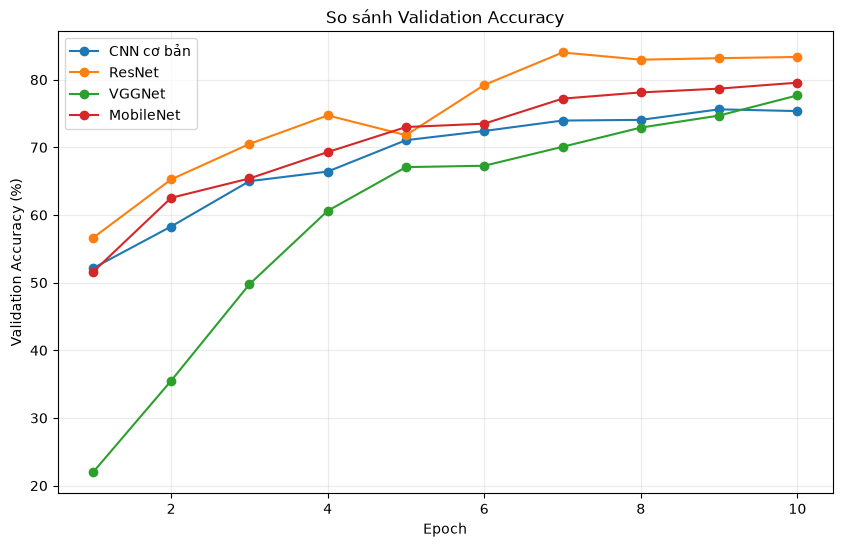

In [ ]:
# Tạo figure.
plt.figure(figsize=(10, 6))

# Duyệt model.
for model_name, history in histories.items():
    # Trục epoch.
    epoch_axis = np.arange(
        1,
        len(history["val_acc"]) + 1,
    )

    # Vẽ val accuracy.
    plt.plot(
        epoch_axis,
        np.array(history["val_acc"]) * 100.0,
        marker="o",
        label=model_name,
    )

# Nhãn trục.
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy (%)")

# Title.
plt.title("So sánh Validation Accuracy")

# Legend.
plt.legend()

# Grid.
plt.grid(alpha=0.25)

# Show.
plt.show()

## 24. Learning Curve — Validation Loss

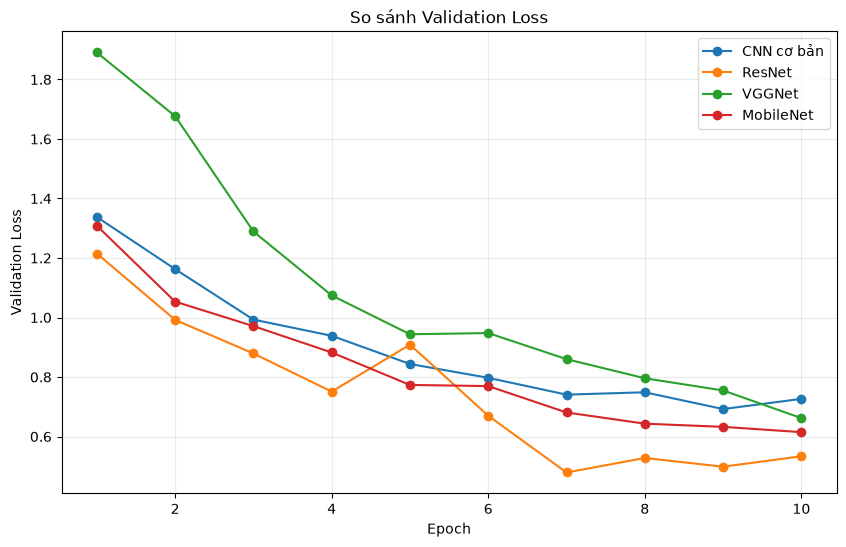

In [ ]:
# Figure.
plt.figure(figsize=(10, 6))

# Duyệt history.
for model_name, history in histories.items():
    # Epoch axis.
    epoch_axis = np.arange(
        1,
        len(history["val_loss"]) + 1,
    )

    # Plot loss.
    plt.plot(
        epoch_axis,
        history["val_loss"],
        marker="o",
        label=model_name,
    )

# Label.
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")

# Title.
plt.title("So sánh Validation Loss")

# Legend.
plt.legend()

# Grid.
plt.grid(alpha=0.25)

# Show.
plt.show()

## 25. So sánh Accuracy / Parameters / Training Time

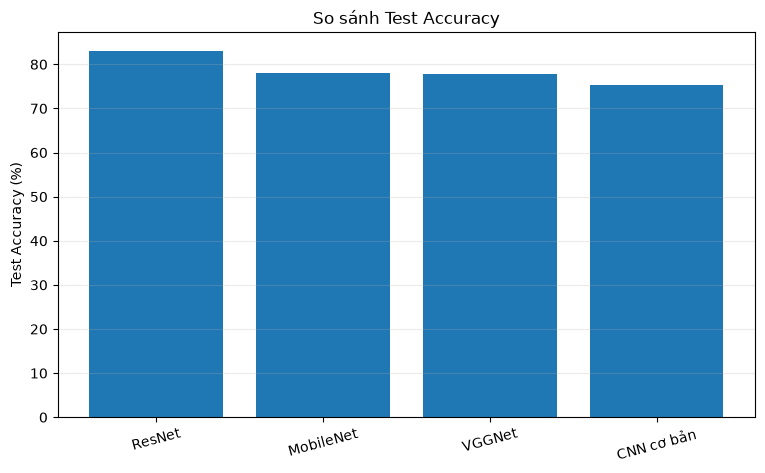

In [ ]:
# Thứ tự model.
plot_models = comparison_df["Model"].tolist()

# Accuracy.
plot_accuracy = comparison_df["Test Accuracy (%)"].to_numpy()

# Figure.
plt.figure(figsize=(9, 5))

# Bar.
plt.bar(
    plot_models,
    plot_accuracy,
)

# Label/title.
plt.ylabel("Test Accuracy (%)")
plt.title("So sánh Test Accuracy")
plt.xticks(rotation=15)
plt.grid(
    axis="y",
    alpha=0.25,
)
plt.show()

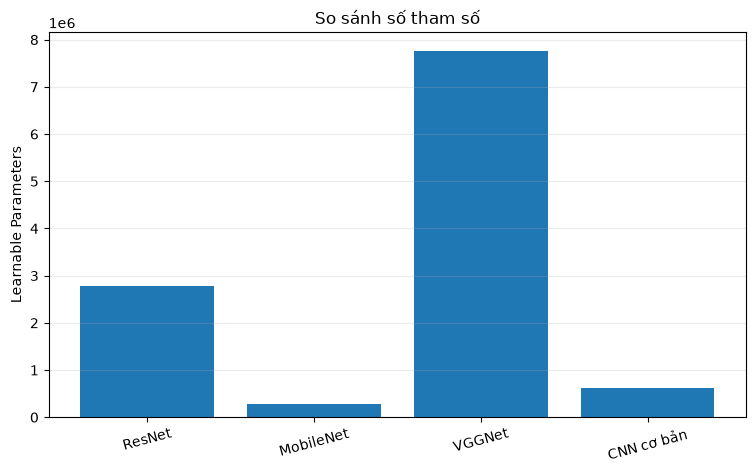

In [ ]:
# Parameter count.
plot_params = comparison_df["Parameters"].to_numpy()

# Figure.
plt.figure(figsize=(9, 5))

# Bar.
plt.bar(
    plot_models,
    plot_params,
)

# Label/title.
plt.ylabel("Learnable Parameters")
plt.title("So sánh số tham số")
plt.xticks(rotation=15)
plt.grid(
    axis="y",
    alpha=0.25,
)
plt.show()

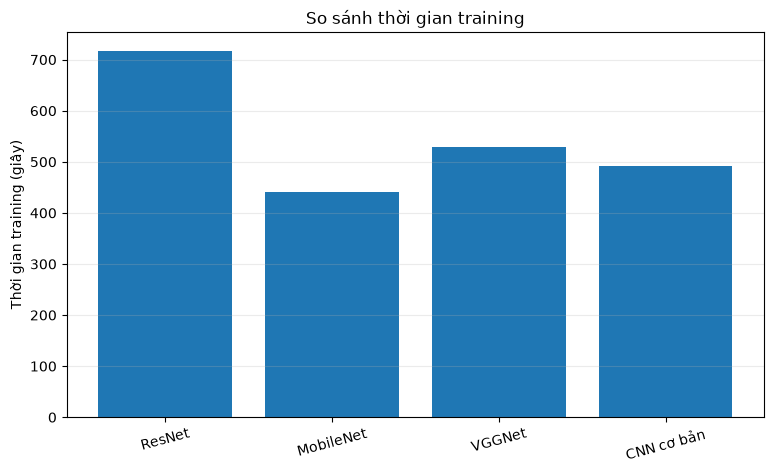

In [ ]:
# Train time.
plot_time = comparison_df["Train Time (s)"].to_numpy()

# Figure.
plt.figure(figsize=(9, 5))

# Bar.
plt.bar(
    plot_models,
    plot_time,
)

# Label/title.
plt.ylabel("Thời gian training (giây)")
plt.title("So sánh thời gian training")
plt.xticks(rotation=15)
plt.grid(
    axis="y",
    alpha=0.25,
)
plt.show()

## 26. Hàm lấy toàn bộ prediction

In [ ]:
# Không gradient.
@torch.no_grad()
def predict_all(
    model: nn.Module,
    loader: DataLoader,
    device: torch.device,
):
    # Eval mode.
    model.eval()

    # List target.
    all_targets = []

    # List prediction.
    all_predictions = []

    # Duyệt batch.
    for images, labels in loader:
        # Đưa ảnh lên device.
        images = images.to(
            device,
            non_blocking=True,
        )

        # Forward.
        logits = model(images)

        # Prediction.
        predictions = logits.argmax(dim=1)

        # Lưu target.
        all_targets.append(labels.cpu().numpy())

        # Lưu prediction.
        all_predictions.append(predictions.cpu().numpy())

    # Ghép tất cả batch.
    y_true = np.concatenate(all_targets)

    # Ghép prediction.
    y_pred = np.concatenate(all_predictions)

    # Return.
    return (
        y_true,
        y_pred,
    )

## 27. Confusion Matrix cho từng mô hình

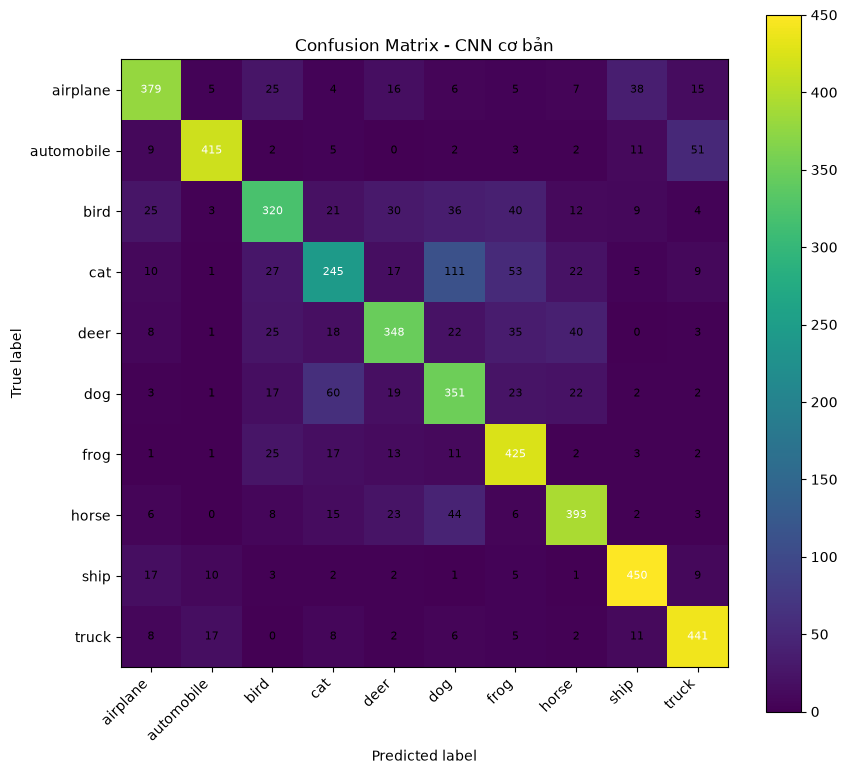

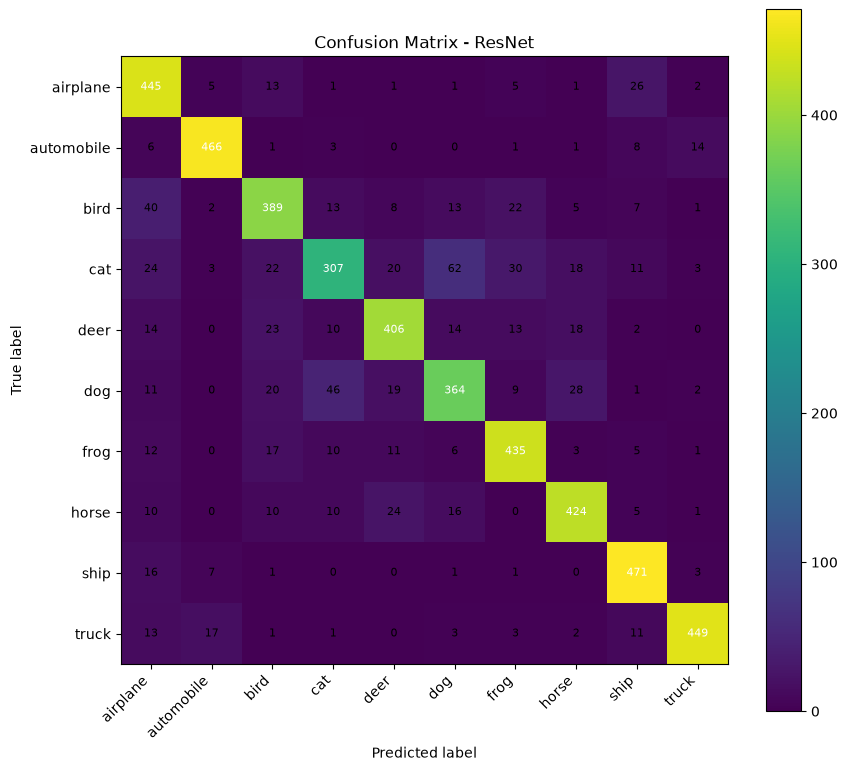

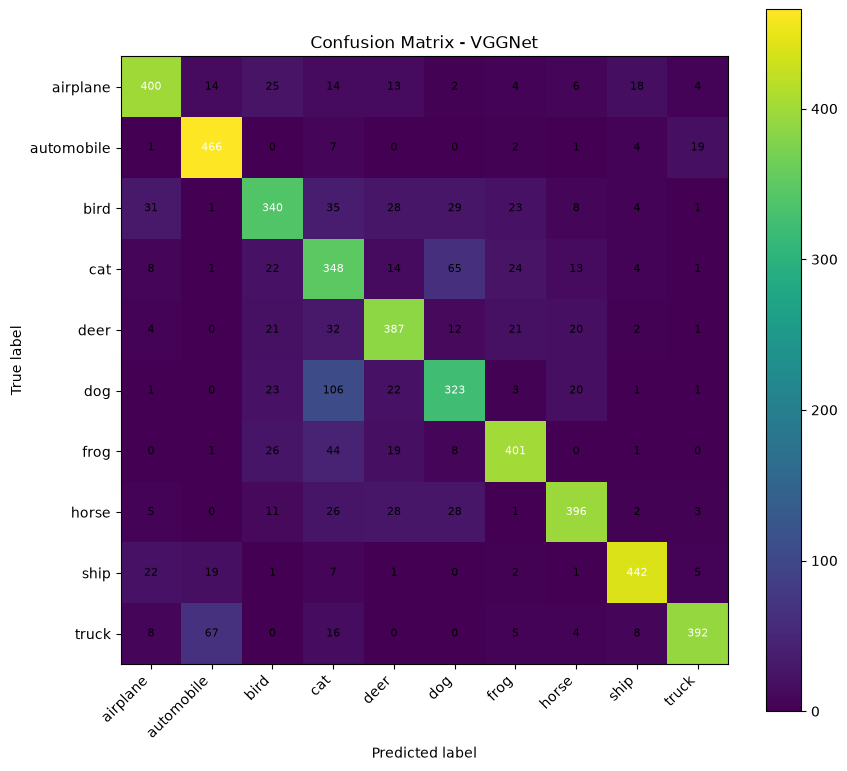

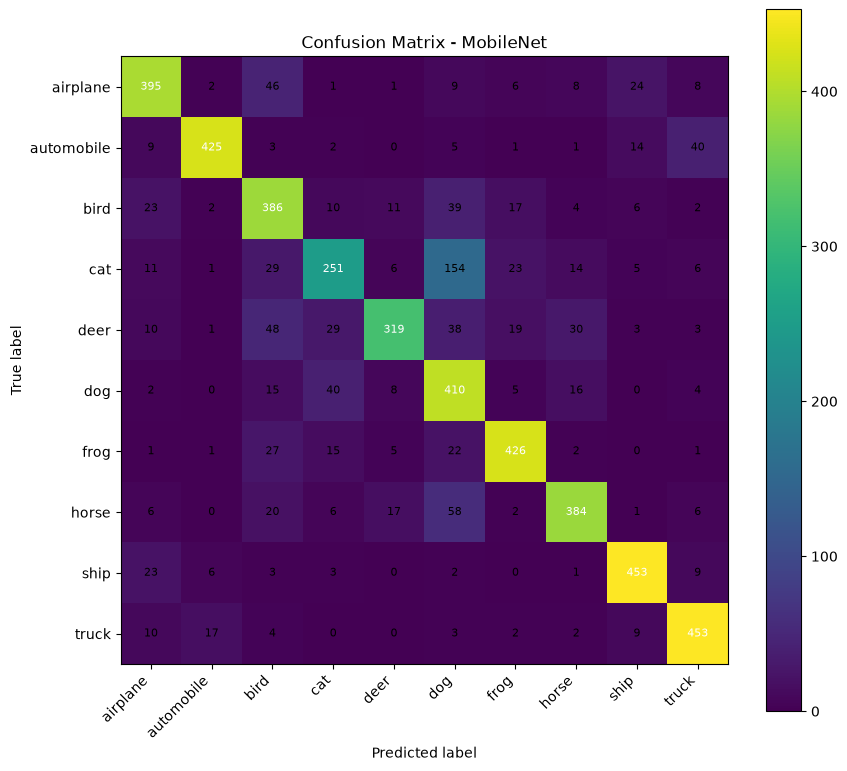

In [ ]:
# Duyệt model đã train.
for model_name, model in trained_models.items():
    # Lấy prediction.
    y_true, y_pred = predict_all(
        model,
        test_loader,
        DEVICE,
    )

    # Confusion matrix.
    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=np.arange(10),
    )

    # Figure.
    plt.figure(figsize=(9, 8))

    # Vẽ matrix.
    plt.imshow(
        cm,
        interpolation="nearest",
    )

    # Colorbar.
    plt.colorbar()

    # Tick labels.
    plt.xticks(
        np.arange(10),
        CLASS_NAMES,
        rotation=45,
        ha="right",
    )

    # Tick labels y.
    plt.yticks(
        np.arange(10),
        CLASS_NAMES,
    )

    # Axis labels.
    plt.xlabel("Predicted label")
    plt.ylabel("True label")

    # Title.
    plt.title(f"Confusion Matrix - {model_name}")

    # Threshold.
    threshold = cm.max() / 2.0

    # Ghi số vào từng ô.
    for row in range(cm.shape[0]):
        for col in range(cm.shape[1]):
            plt.text(
                col,
                row,
                str(
                    cm[
                        row,
                        col,
                    ]
                ),
                ha="center",
                va="center",
                color=(
                    "white"
                    if cm[
                        row,
                        col,
                    ]
                    > threshold
                    else "black"
                ),
                fontsize=8,
            )

    # Tight layout.
    plt.tight_layout()

    # Show.
    plt.show()

## 28. Classification Report

In [ ]:
# Duyệt model.
for model_name, model in trained_models.items():
    # Prediction.
    y_true, y_pred = predict_all(
        model,
        test_loader,
        DEVICE,
    )

    # Separator.
    print("\n" + "=" * 80)

    # Model name.
    print(model_name)

    # Report.
    print(
        classification_report(
            y_true,
            y_pred,
            labels=np.arange(10),
            target_names=CLASS_NAMES,
            digits=4,
            zero_division=0,
        )
    )


CNN cơ bản
              precision    recall  f1-score   support

    airplane     0.8133    0.7580    0.7847       500
  automobile     0.9141    0.8300    0.8700       500
        bird     0.7080    0.6400    0.6723       500
         cat     0.6203    0.4900    0.5475       500
        deer     0.7404    0.6960    0.7175       500
         dog     0.5949    0.7020    0.6440       500
        frog     0.7083    0.8500    0.7727       500
       horse     0.7813    0.7860    0.7836       500
        ship     0.8475    0.9000    0.8729       500
       truck     0.8182    0.8820    0.8489       500

    accuracy                         0.7534      5000
   macro avg     0.7546    0.7534    0.7514      5000
weighted avg     0.7546    0.7534    0.7514      5000


ResNet
              precision    recall  f1-score   support

    airplane     0.7530    0.8900    0.8158       500
  automobile     0.9320    0.9320    0.9320       500
        bird     0.7827    0.7780    0.7803       500
    

## 29. Visualization prediction mẫu

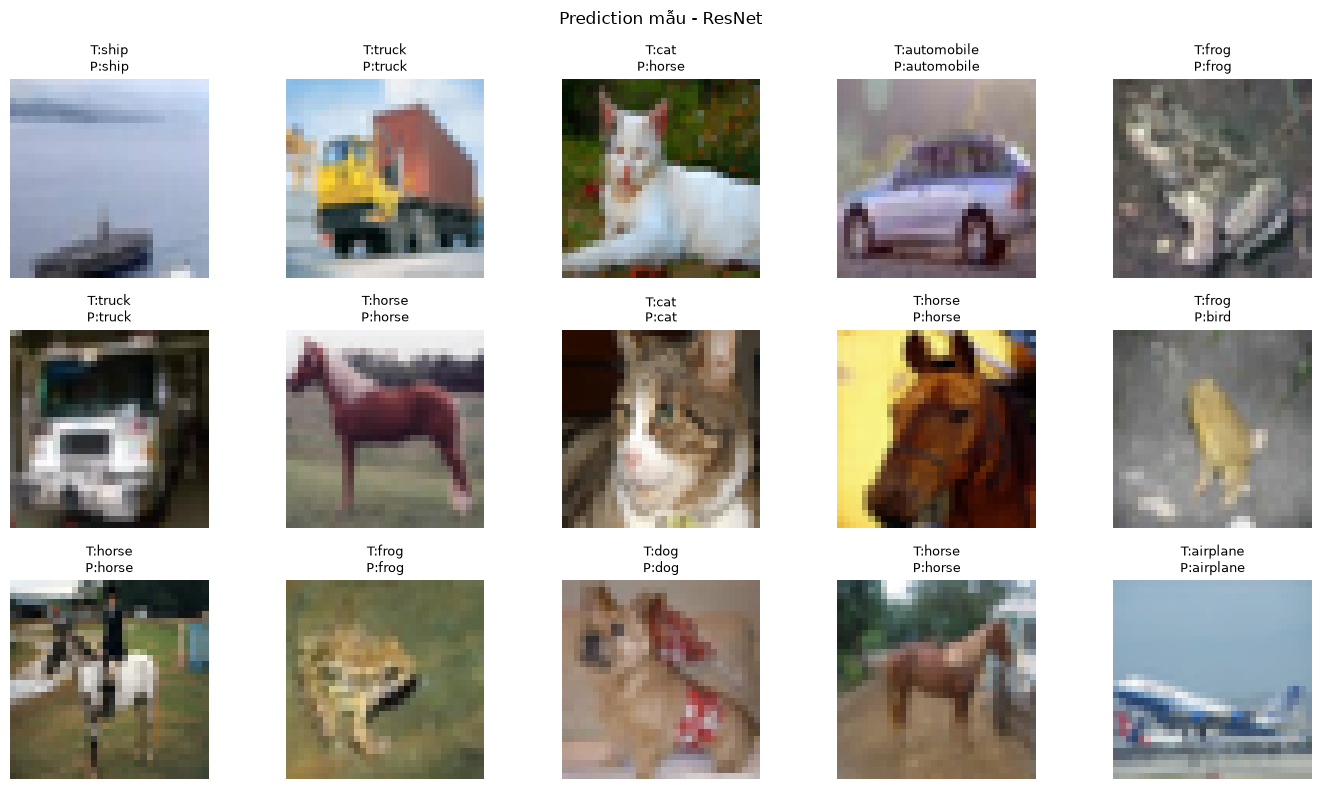

In [ ]:
# Chọn model có Test Accuracy tốt nhất.
best_model_name = comparison_df.iloc[0]["Model"]

# Lấy model.
best_model = trained_models[best_model_name]

# Eval mode.
best_model.eval()

# Lấy một batch test.
test_images_batch, test_labels_batch = next(iter(test_loader))

# Inference.
with torch.no_grad():
    # Logits.
    logits = best_model(test_images_batch.to(DEVICE))

    # Prediction.
    predicted_batch = logits.argmax(dim=1).cpu()

# Figure.
plt.figure(figsize=(14, 8))

# Hiển thị 15 ảnh.
for i in range(15):
    # Subplot.
    plt.subplot(
        3,
        5,
        i + 1,
    )

    # Đảo normalize.
    image = denormalize_image(test_images_batch[i])

    # [C,H,W] -> [H,W,C].
    image = image.permute(
        1,
        2,
        0,
    ).numpy()

    # Plot.
    plt.imshow(image)

    # Label thật.
    true_idx = int(test_labels_batch[i])

    # Prediction.
    pred_idx = int(predicted_batch[i])

    # Tên class.
    true_name = INDEX_TO_CLASS[true_idx]
    pred_name = INDEX_TO_CLASS[pred_idx]

    # Title.
    plt.title(
        f"T:{true_name}\nP:{pred_name}",
        fontsize=9,
    )

    # Off axis.
    plt.axis("off")

# Suptitle.
plt.suptitle(f"Prediction mẫu - {best_model_name}")

# Layout.
plt.tight_layout()

# Show.
plt.show()

## 30. Lưu model, metric và preprocessing config

In [ ]:
# Output directory cạnh notebook.
OUTPUT_DIR = Path.cwd() / "outputs_cifar10_cnn"

# Tạo folder.
OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

# Filename an toàn.
safe_names = {
    "CNN cơ bản": "basic_cnn",
    "ResNet": "resnet",
    "VGGNet": "vggnet",
    "MobileNet": "mobilenet",
}

# Lưu model.
for model_name, model in trained_models.items():
    # Path.
    model_path = OUTPUT_DIR / f"{safe_names[model_name]}.pt"

    # Copy state_dict về CPU.
    cpu_state_dict = {key: value.detach().cpu() for key, value in model.state_dict().items()}

    # Save.
    torch.save(
        cpu_state_dict,
        model_path,
    )

    # Print.
    print(
        "Saved:",
        model_path,
    )

# Lưu bảng comparison.
comparison_csv = OUTPUT_DIR / "model_comparison.csv"

# Write CSV.
comparison_df.to_csv(
    comparison_csv,
    index=False,
)

# Print.
print(
    "Saved:",
    comparison_csv,
)

# Lưu preprocessing config.
preprocess_config = pd.DataFrame(
    [
        {
            "mean_r": TRAIN_MEAN[0],
            "mean_g": TRAIN_MEAN[1],
            "mean_b": TRAIN_MEAN[2],
            "std_r": TRAIN_STD[0],
            "std_g": TRAIN_STD[1],
            "std_b": TRAIN_STD[2],
            "height": 32,
            "width": 32,
            "channels": 3,
        }
    ]
)

# Config path.
preprocess_path = OUTPUT_DIR / "preprocessing_config.csv"

# Save.
preprocess_config.to_csv(
    preprocess_path,
    index=False,
)

# Print.
print(
    "Saved:",
    preprocess_path,
)

Saved: c:\Users\datng\Desktop\GIÁO TRÌNH\NĂM 4 - KÌ 1\PTCHTTH - Phát Triển Các Hệ Thống Thông Minh\test\a05\data2_cifar_10\outputs_cifar10_cnn\basic_cnn.pt
Saved: c:\Users\datng\Desktop\GIÁO TRÌNH\NĂM 4 - KÌ 1\PTCHTTH - Phát Triển Các Hệ Thống Thông Minh\test\a05\data2_cifar_10\outputs_cifar10_cnn\resnet.pt
Saved: c:\Users\datng\Desktop\GIÁO TRÌNH\NĂM 4 - KÌ 1\PTCHTTH - Phát Triển Các Hệ Thống Thông Minh\test\a05\data2_cifar_10\outputs_cifar10_cnn\vggnet.pt
Saved: c:\Users\datng\Desktop\GIÁO TRÌNH\NĂM 4 - KÌ 1\PTCHTTH - Phát Triển Các Hệ Thống Thông Minh\test\a05\data2_cifar_10\outputs_cifar10_cnn\mobilenet.pt
Saved: c:\Users\datng\Desktop\GIÁO TRÌNH\NĂM 4 - KÌ 1\PTCHTTH - Phát Triển Các Hệ Thống Thông Minh\test\a05\data2_cifar_10\outputs_cifar10_cnn\model_comparison.csv
Saved: c:\Users\datng\Desktop\GIÁO TRÌNH\NĂM 4 - KÌ 1\PTCHTTH - Phát Triển Các Hệ Thống Thông Minh\test\a05\data2_cifar_10\outputs_cifar10_cnn\preprocessing_config.csv


# 31. Gợi ý phân tích kết quả

Sau khi chạy xong, không chỉ nhìn Accuracy.

Hãy so sánh:

- **CNN cơ bản**: baseline đơn giản.
- **ResNet**: residual connection có giúp hội tụ tốt hơn không?
- **VGGNet**: nhiều `Conv 3×3` có tăng accuracy nhưng làm model nặng hơn không?
- **MobileNet**: giảm parameters mạnh tới mức nào và accuracy bị ảnh hưởng ra sao?
- **Validation curve**: có overfitting không?
- **Confusion matrix**: lớp nào hay nhầm với nhau?
- **Training time**: kiến trúc nào phù hợp hơn với tài nguyên máy?

Với CIFAR-10, thường nên huấn luyện nhiều epoch hơn MNIST để chênh lệch kiến trúc thể hiện rõ hơn.